In [1]:
from pathlib import Path
import csv
import datetime
import os
import sys
from dataclasses import dataclass
from typing import List, Tuple

notebook_dir = Path(os.getcwd())
project_root_dir = notebook_dir.parent
if str(project_root_dir) not in sys.path:
    sys.path.insert(0, str(project_root_dir))

import seaborn as sns
import matplotlib.pyplot as plt
import pyrallis
import pandas as pd
import numpy as np

from config import Config, TrainConfig
import logs

In [19]:
study_dir = project_root_dir.joinpath("logs/hgf-20p")
trials_all = logs.read_study(study_dir)
df_all = logs.create_df(trials_all)
len(trials_all)

81

In [21]:
trials = []
for t in trials_all:
    if int(t.name[:8]) <= 20250611 and int(t.name[10:15]) <= 203612:
        trials.append(t)

df_till_now = logs.create_df(trials)

In [33]:
df_all['val_loss'].min()

np.float64(0.020573890745459785)

In [22]:
df = df_till_now.query("optimizer == 'adagrad' & lr == 0.1 & weight_decay == 0 & init == 'ku' & loss == 'smoothl1' & batch_size == 1024 & activation == 'tanh'")
df['hidden_layers'] = df['hidden_layers'].astype(str)
df.query('epoch == 100')

/tmp/ipykernel_250902/3369691458.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['hidden_layers'] = df['hidden_layers'].astype(str)


,name,loss,batch_size,init,init_param,activation,hidden_layers,dropout,optimizer,lr,weight_decay,train_time,epoch,train_loss,val_loss
99,20250611-203612-XkVw,smoothl1,1024,ku,[],tanh,"[74, 74, 74]",[],adagrad,0.1,0.0,128.583333,100,0.019901,0.020603
399,20250611-203612-zGUd,smoothl1,1024,ku,[],tanh,"[74, 74]",[],adagrad,0.1,0.0,124.716667,100,0.019901,0.020602
2799,20250611-170718-jWDv,smoothl1,1024,ku,[],tanh,[512],[],adagrad,0.1,0.0,174.283333,100,0.020018,0.020683
3899,20250611-170718-Elqh,smoothl1,1024,ku,[],tanh,[128],[],adagrad,0.1,0.0,171.433333,100,0.019897,0.020606
4499,20250611-170718-ZhXo,smoothl1,1024,ku,[],tanh,[74],[],adagrad,0.1,0.0,165.533333,100,0.019883,0.020605
4999,20250611-203612-nqiR,smoothl1,1024,ku,[],tanh,"[74, 74, 74, 74, 74]",[],adagrad,0.1,0.0,108.150000,100,0.019898,0.020587
6099,20250611-203612-tWhb,smoothl1,1024,ku,[],tanh,"[74, 128, 74]",[],adagrad,0.1,0.0,100.350000,100,0.019898,0.020600
6999,20250611-203612-Dxag,smoothl1,1024,ku,[],tanh,"[74, 128, 128, 74]",[],adagrad,0.1,0.0,128.350000,100,0.019896,0.020591
7199,20250611-203612-nWFW,smoothl1,1024,ku,[],tanh,"[74, 74, 74, 74]",[],adagrad,0.1,0.0,131.933333,100,0.019900,0.020620


[None]

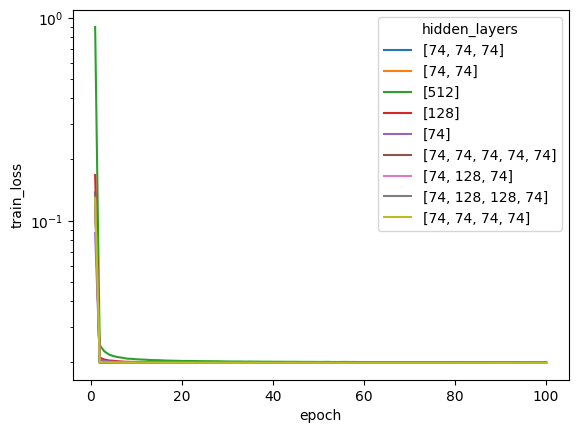

In [23]:
ax = sns.lineplot(df, x='epoch', y='train_loss', hue='hidden_layers')
ax.set(yscale='log')

[None]

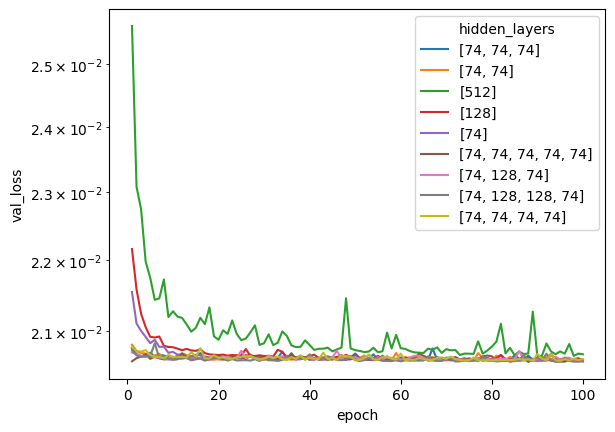

In [24]:
ax = sns.lineplot(df, x='epoch', y='val_loss', hue='hidden_layers')
ax.set(yscale='log')

In [29]:
df.query('epoch == 100').groupby(['hidden_layers'])['val_loss'].min().sort_values()

hidden_layers
[74, 74, 74, 74, 74]    0.020587
[74, 128, 128, 74]      0.020591
[74, 128, 74]           0.020600
[74, 74]                0.020602
[74, 74, 74]            0.020603
[74]                    0.020605
[128]                   0.020606
[74, 74, 74, 74]        0.020620
[512]                   0.020683
Name: val_loss, dtype: float64

In [30]:
df['val_loss'].min()

np.float64(0.020580711237407606)

In [32]:
df_till_now['val_loss'].min()

np.float64(0.020573890745459785)